In [353]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum
from utils import modeling_did


# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}

tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

In [6]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\571702545.py:3: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [7]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())

df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)

ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64
object


In [8]:
# df_all["time"]=df_all["time"].astype(str)
# df_all['trend'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***
print(df_all[['in_paris',"time","trend","post"]].value_counts(dropna=False))
# print(df_all['time'].dtype)
# df_all['time']=df_all['time'].astype(str)

in_paris  time  trend  post
1         2406  2      1       62738
0         2406  2      1       49856
          2312  1      0       43172
          2306  0      0       42356
1         2312  1      0       35829
          2306  0      0       32901
Name: count, dtype: int64


In [9]:
# df_all.to_csv(path_df, index=False)

## pre trend check

In [5]:
df_pre=df_all[df_all['time']!="2406"]
print(df_pre.shape)
print(df_pre[['time','in_paris']].value_counts())

(266852, 125)
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [147]:
## pre trend check!!!

# booking_rate_l90d
df=df_pre.copy()
formula= (" booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time)"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
summary=model.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     2802.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:54:56   Log-Likelihood:                 88109.
No. Observations:              266852   AIC:                        -1.762e+05
Df Residuals:                  266824   BIC:                        -1.759e+05
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# tactic~


## + trend: "C(time) + in_paris*trend + in_paris * post"


In [ ]:

# ✔ 1. C(time) # 控制所有城市共同的时间变化（宏观趋势）
# ✔ 2. in_paris * trend # 允许 Paris 和 London 有不同的趋势（解决你发现的不平行问题）
# ✔ 3. in_paris * post # 👉 在控制趋势差异之后，识别 JO 的“额外冲击”

# 在控制了城市固定差异、时间效应以及城市特定趋势（city-specific trends）之后，
# in_paris × post 捕捉了 2024年巴黎奥运会 对 Paris 相对于 London 的“额外变化”（differential change）

# 优点： 清晰、好解释（有一个系数）
# 缺点： 强结构假设的 DiD（parametric DiD）：
# pre-trend 是线性的
# treatment effect 是“一个跳跃 + 一个趋势修正”


In [10]:
def run_tactic_model_by_trend(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris*trend + in_paris * post"
    )
              
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) +"
            # "pic_no_person + pic_pro_style + pic_life_style +"
            # " is_smiling + "
            # "C(age_class) + C(gender) +"
            
    model_tactic=smf.ols(formula, data=df).fit()
    # summary=model_tactic.summary()
    # print(summary)
    return model_tactic

df=df_all.copy()

results=[]
for var in tactics_bio:
    print(var)
    model=run_tactic_model_by_trend(df, var)
    term="in_paris:post"
    coef = model.params[term]
    se = model.bse[term]
    pval = model.pvalues[term]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })
results_df = pd.DataFrame(results)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [11]:
results_df

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.009624,0.010803,0.373031,,-0.030798,0.011551
1,authenticité,-0.015611,0.011191,0.163017,,-0.037545,0.006323
2,sociabilité,-0.009865,0.011565,0.393671,,-0.032532,0.012803
3,auto_promotion,0.042751,0.010544,0.000050,***,0.022086,0.063417
4,exemplarité,0.044509,0.011202,0.000071,***,0.022553,0.066464


<Figure size 640x480 with 0 Axes>

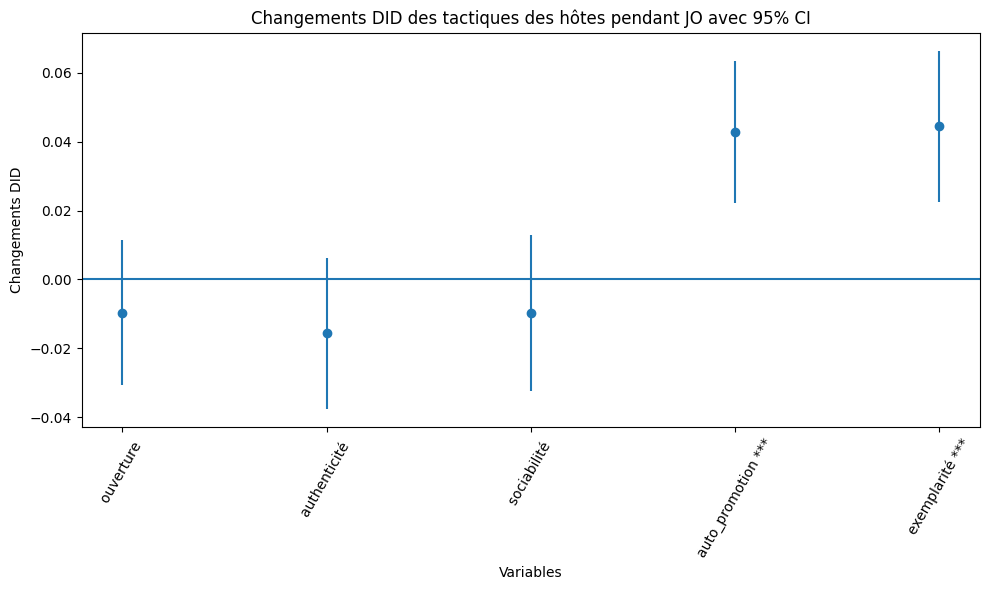

In [46]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## event study :C(time) + in_paris * C(time)


In [ ]:
## event study :C(time) + in_paris * C(time)
# 不假设差异趋势是线性的
# # 弱假设 / 非参数 DiD（event study）：[更加稳健]
# 每个时间点可以自由变化,不强制趋势形状
##==允许：2312 下跌，2406 反弹，不规则变化

# C(time)固定时间变化（季节，整体增长）
# 交互项：paris(相对于london)[在每个时间点]的额外变化

# | 时间   | Paris 相对 London 的差异 |
# | ---- | ------------------- |
# | 2306 | baseline（被省略）     |
# | 2312 | β₁（pre-trend）       |
# | 2406 | β₂（JO + trend）      |
# JO effect ≈ β_2406 - β_2312 (24差异减去稳定差异==jo额外差异)

# 线性组合计算β_2406 - β_2312 = 0 ?


##结果差异，不仅因为数据不稳定，还有模型假设的差异

In [12]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time

df=df_all.copy()
model_tactic=run_tactic_model_by_time(df, y="authenticité")
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2007.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:54:22   Log-Likelihood:            -2.6399e+05
No. Observations:              266852   AIC:                         5.280e+05
Df Residuals:                  266824   BIC:                         5.283e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:

## XXXXX真实效应组成:
#这里观察的时y的变化！

# london 2306: baseline
# london 2312 :  C(time)[T.2312]
# london 2406 :  C(time)[T.2406]

# paris 2306: in_paris
# paris 2312 :  in_paris:C(time)[T.2312]
# paris 2406 :  in_paris:C(time)[T.2406]

### ???
# delta 2306: in_paris
# delta 2312 : in_paris:C(time)[T.2312]- C(time)[T.2312]
# delta 2406 : in_paris:C(time)[T.2406]- C(time)[T.2406]


In [321]:
# event study 图：Paris 相对于 London，在不同时间点的“动态差异路径”

importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect

var="authenticité"
model=model_tactic
data=get_event_study_data(model, var=var)
display(data)

ddd=get_ddd_effect(model, var=var)
display(ddd)




,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***


authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,0.014043,0.006106,0.021454,*,0.002076,0.026011


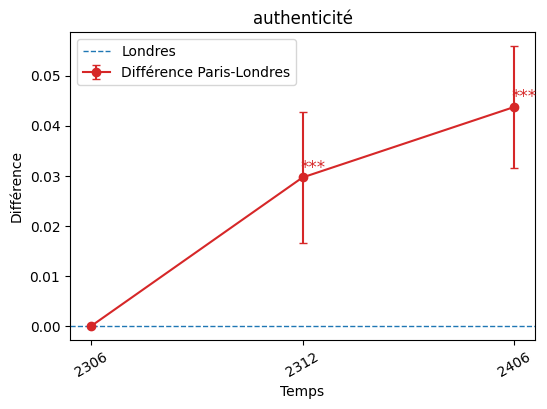

In [322]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

plot_one_did(data,axes=None, var='authenticité')

In [15]:
df=df_all.copy()
data_list=[]
for i, y in enumerate(tactics_bio):
    # if i >1:
    #     break  
    print (i, y)
    model=run_tactic_model_by_time(df, y)
    data = get_event_study_data(model, var=y)
    data_list.append(data)
data_all=pd.concat(data_list, axis=0)
data_all

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,,2306
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,,2312
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,,2406
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,,2306
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**,2312 **
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***,2406 ***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,,2306


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3401378956.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


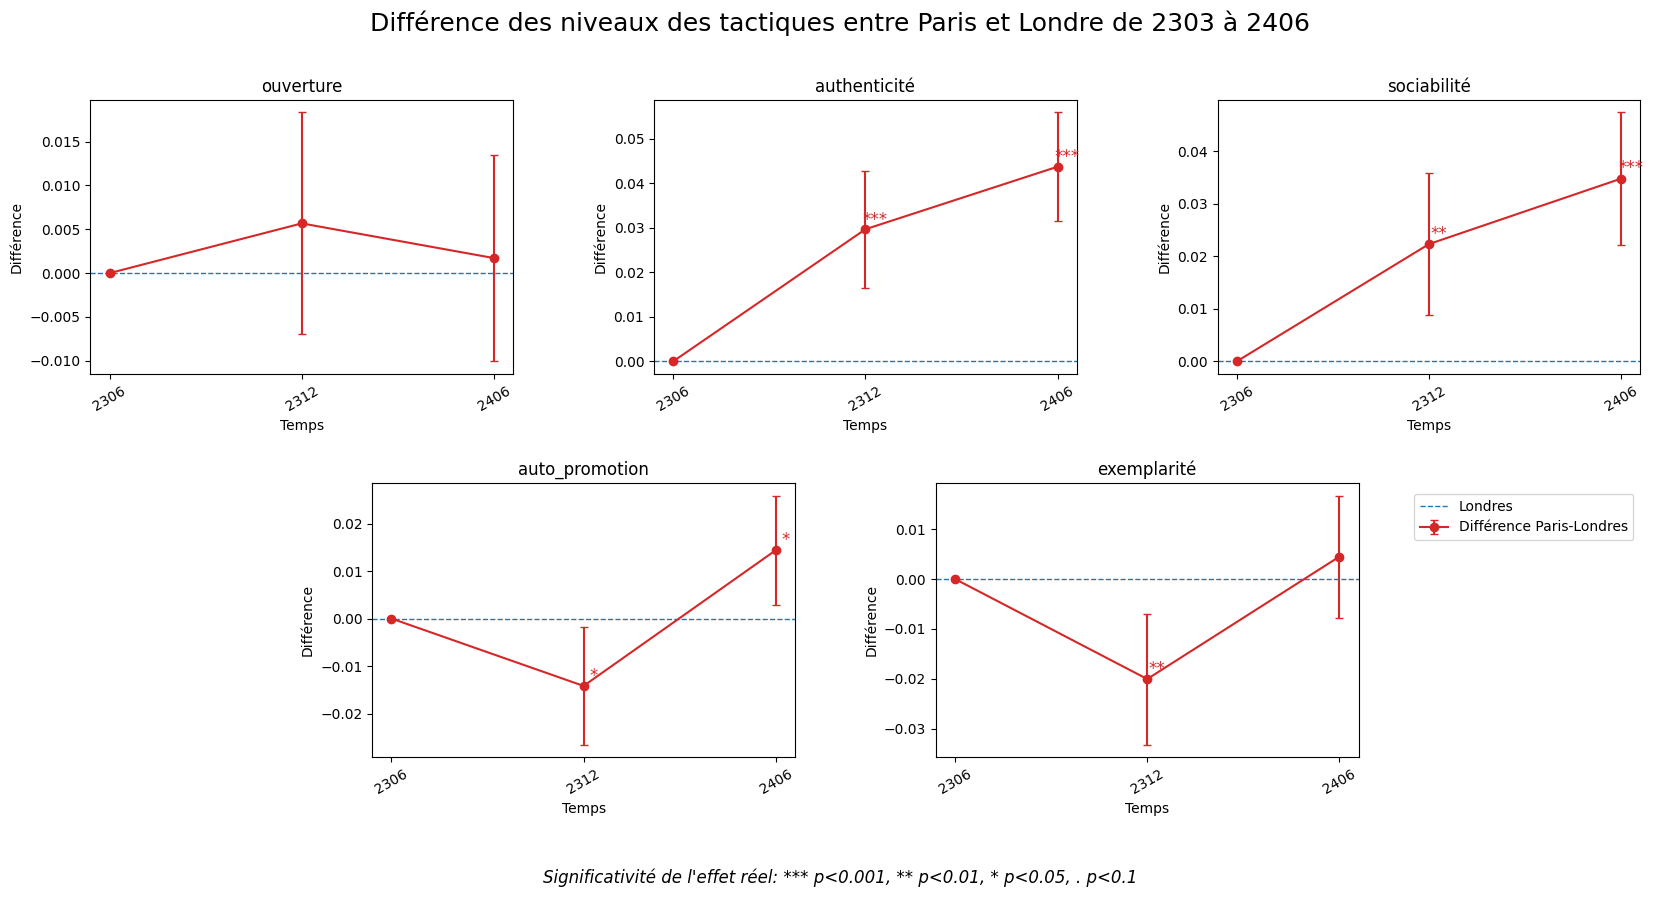

In [317]:
 
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

## plot
# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


for i, var in enumerate(tactics_bio):
    plot_one_did(data=data_all, axes=axes, i=i, var=var)
fig.suptitle(
        "Différence des niveaux des tactiques entre Paris et Londre de 2303 à 2406",
        fontsize=18,
        y=0.98
    )


# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------

# 在event study，不对趋势形状做任何假设，如果不存在jo，我们认为2406的差异和2312一样，两个点处于一条水平线上
# 所以jo的效应偏离这条差异水平线
# 如果trend是线性的，2406没有jo的差异会落在延长线上，表示两地的差异不断扩大

# ------------------------RESULTS--------------------------

# 在蓝线智商说明paris比london的平均水平高
# 横向对比：1232 VS 2406的垂直差异 代表JO 期间策略变化的大小

# 在2406：
# ouverture差异缩小
# auth, socio差异扩大
# auto差异相似，但是反超：原本london更多auto，但是jo期间大幅增多
# exem差异缩小，大幅增多，超过london

### predict line+ counterfactual line

In [323]:
df=df_all.copy()
y='authenticité'
model=run_tactic_model_by_time(df, y)


In [324]:
ddd=get_ddd_effect(model, var=y)
display(ddd)

authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,0.014043,0.006106,0.021454,*,0.002076,0.026011


ddd of authenticité: 0.014043224391017566


,in_paris,time,y_hat,y_cf,variable
0,0,2306,-0.181066,-0.181066,authenticité
1,0,2312,-0.204839,-0.204839,authenticité
2,0,2406,-0.216109,-0.216109,authenticité
3,1,2306,-0.158274,-0.158274,authenticité
4,1,2312,-0.155755,-0.155755,authenticité
5,1,2406,-0.144402,-0.158445,authenticité


axis x : [0, 1, 2]


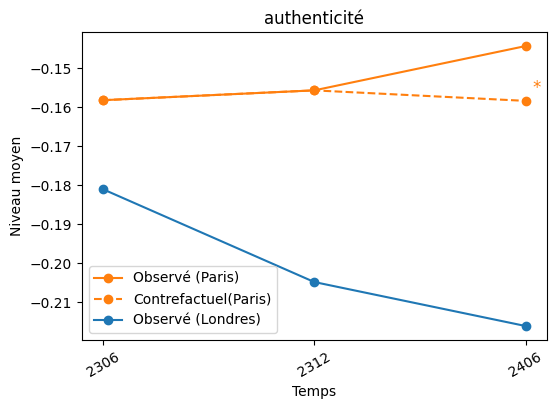

In [334]:
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data, plot_one_cf

var="authenticité"
agg=get_cf_data(df, model, var=var)
ddd_sig=ddd[ddd['variable']==var]['sig'].iloc[0]
plot_one_cf(agg, axes=None, i=0, var=var, ddd_sig=ddd_sig)


In [20]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

agg_list=[]
ddd_list=[]

for i, y in enumerate(tactics_bio):
    # print(i, y)
    df=df_all.copy()
    model=run_tactic_model_by_time(df, y)
    ddd=get_ddd_effect(model, var=y)
    agg=get_cf_data(df, model, var=y)
    ddd_list.append(ddd)
    agg_list.append(agg)
    # plot_one_cf(agg, axes=None, i=0, var=y)
df_ddd=pd.concat(ddd_list, axis=0)
df_agg=pd.concat(agg_list, axis=0)


ouverture
ouverture
ddd of ouverture: -0.003955410205441894
authenticité
authenticité
ddd of authenticité: 0.014043224391017566
sociabilité
sociabilité
ddd of sociabilité: 0.012459292106811095
auto_promotion
auto_promotion
ddd of auto_promotion: 0.028563511199381705
exemplarité
exemplarité
ddd of exemplarité: 0.024491717931886266


In [335]:
display(df_agg)
display(df_ddd)


,in_paris,time,y_hat,y_cf,variable
0,0,2306,-0.111349,-0.111349,ouverture
1,0,2312,-0.111726,-0.111726,ouverture
2,0,2406,-0.113564,-0.113564,ouverture
3,1,2306,-0.093083,-0.093083,ouverture
4,1,2312,-0.083193,-0.083193,ouverture
5,1,2406,-0.088205,-0.084249,ouverture
0,0,2306,-0.181066,-0.181066,authenticité
1,0,2312,-0.204839,-0.204839,authenticité
2,0,2406,-0.216109,-0.216109,authenticité
3,1,2306,-0.158274,-0.158274,authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\1958572202.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


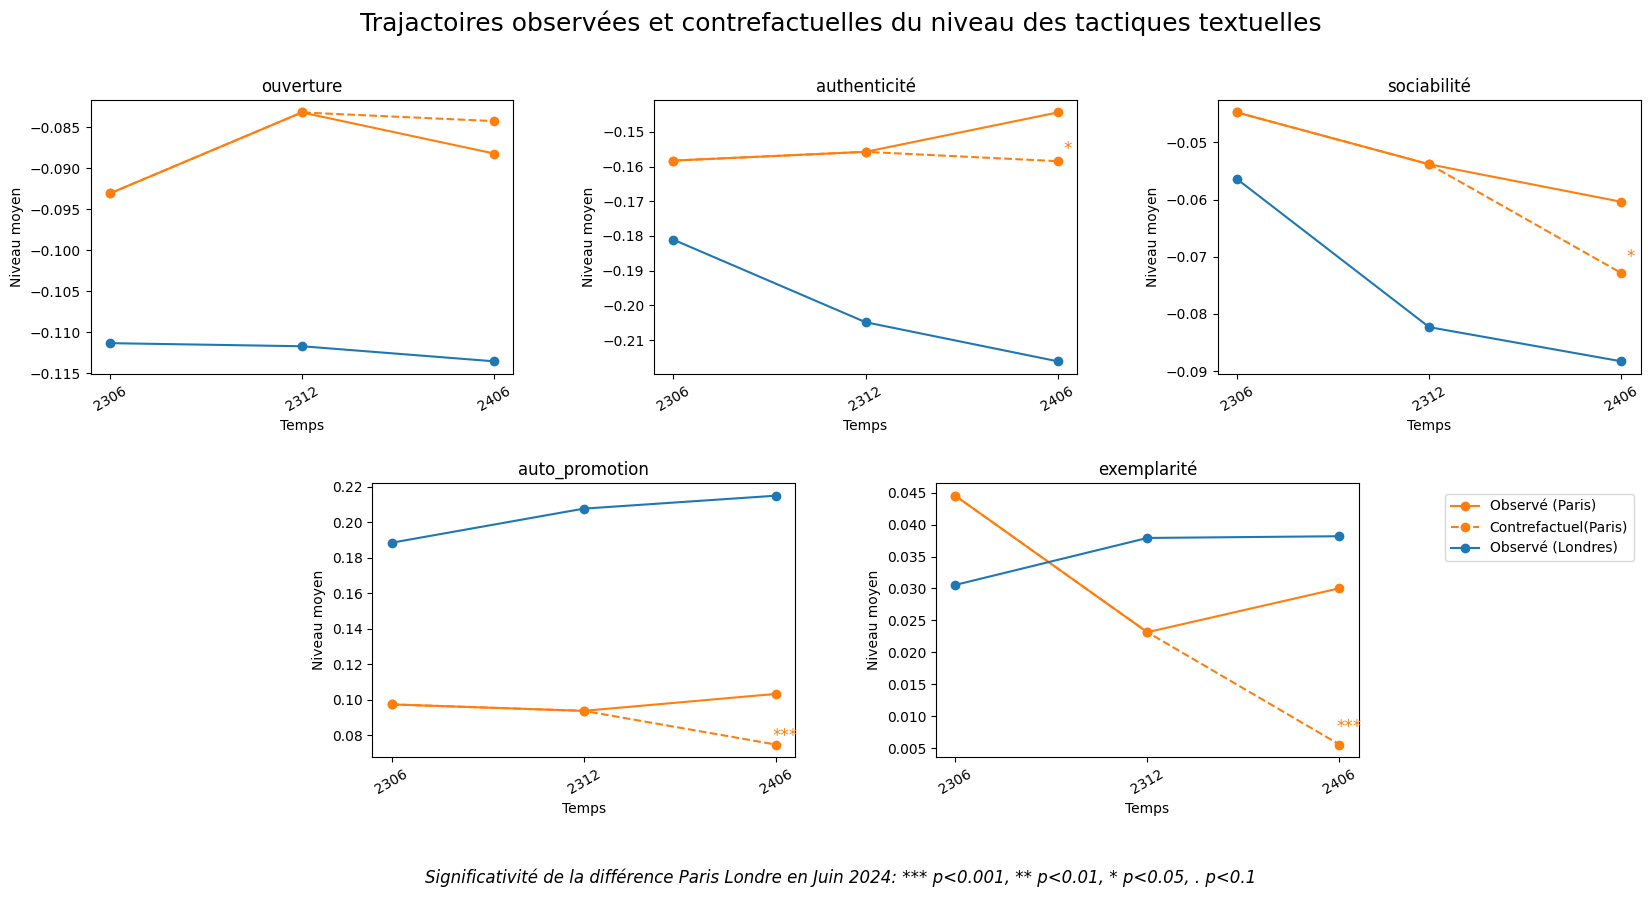

In [337]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:
for i, var in enumerate(tactics_bio):
    print(var)
    agg=df_agg[df_agg['variable']==var]
    ddd_sig=df_ddd[df_ddd['variable']==var]['sig'].loc[0]
    plot_one_cf(agg, axes=axes, i=i,  var=var, ddd_sig=ddd_sig)


# layout:
fig.suptitle(
        "Trajactoires observées et contrefactuelles du niveau des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence Paris Londre en Juin 2024: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------

#
 

## cat var

In [351]:
# porportion变化

df=df_all.copy()
df['is_portrait']=df["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
print(df['is_portrait'].value_counts(dropna=False))



is_portrait
0    172204
1     94648
Name: count, dtype: int64


,time,in_paris,is_portrait
0,2306,0,0.329871
1,2306,1,0.379533
2,2312,0,0.331419
3,2312,1,0.371682
4,2406,0,0.327503
5,2406,1,0.386305


<Axes: xlabel='time', ylabel='is_portrait'>

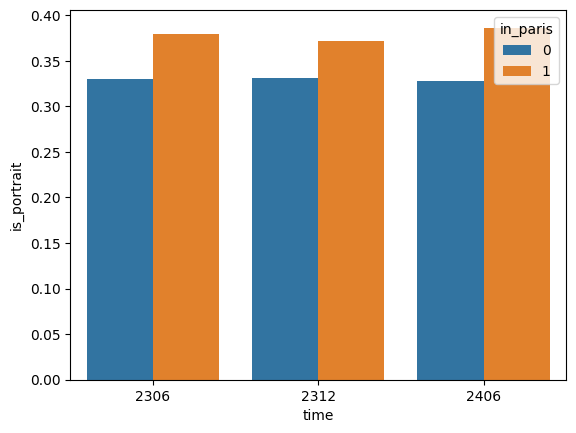

In [352]:
agg_pic=df.groupby(['time','in_paris'])['is_portrait'].mean().reset_index()
display(agg_pic)

import seaborn as sns

sns.barplot(
    data=agg_pic,
    x='time',
    y="is_portrait",
    hue="in_paris"
)

In [350]:
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:            is_portrait   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     704.9
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:34:56   Log-Likelihood:            -1.7271e+05
No. Observations:              266852   AIC:                         3.455e+05
Df Residuals:                  266824   BIC:                         3.458e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,is_portrait,NaN,NaN,,2306
1,2312,-0.006704,-0.016007,0.002600,is_portrait,0.004747,0.157896,,2312
2,2406,0.010450,0.001794,0.019106,is_portrait,0.004416,0.017971,*,2406 *


is_portrait


,variable,coef,se,pval,sig,ci_low,ci_high
0,is_portrait,0.017154,0.004337,0.000077,***,0.008653,0.025654


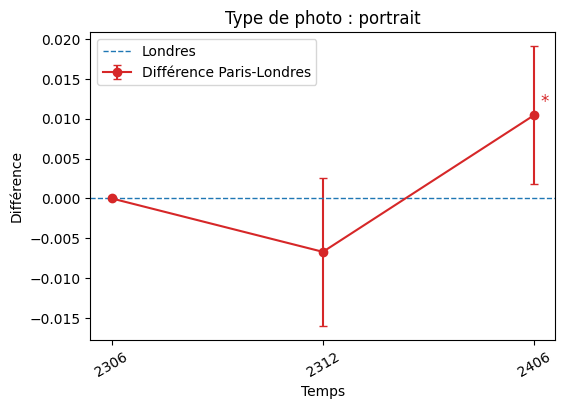

In [348]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

var="is_portrait"
model_tactic=run_tactic_model_by_time(df, y=var)

data=get_event_study_data(model_tactic, var=var)
display(data)

ddd=get_ddd_effect(model_tactic, var=var)
display(ddd)

plot_one_did(data,axes=None, var=var, title='Type de photo : portrait')


,time,in_paris,is_portrait
0,2306,0,0.329871
1,2306,1,0.379533
2,2312,0,0.331419
3,2312,1,0.371682
4,2406,0,0.327503
5,2406,1,0.386305


<Axes: xlabel='time', ylabel='is_portrait'>

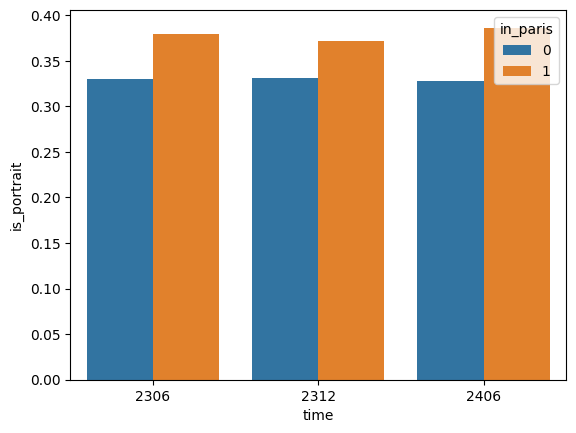

# booking_rate~

In [24]:

df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) +"
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) +"
        "C(time) + in_paris*C(time)"
)
df=df_all.copy()
model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     5209.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:56:44   Log-Likelihood:                 88301.
No. Observations:              266852   AIC:                        -1.765e+05
Df Residuals:                  266817   BIC:                        -1.762e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [25]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect


var="booking_rate_l90d"
data_booking=get_event_study_data(model=model_basic, var=var)
display(data_booking)
print(data_booking.time.dtype)
ddd=get_ddd_effect(model=model_basic, var=var)
ddd


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,booking_rate_l90d,NaN,NaN,,2306
1,2312,-0.030423,-0.033922,-0.026924,booking_rate_l90d,0.001785,4.303327e-65,***,2312 ***
2,2406,-0.058139,-0.061395,-0.054884,booking_rate_l90d,0.001661,9.234794e-268,***,2406 ***


object
booking_rate_l90d


,variable,coef,se,pval,sig,ci_low,ci_high
0,booking_rate_l90d,-0.027717,0.001631,1.024722e-64,***,-0.030914,-0.02452


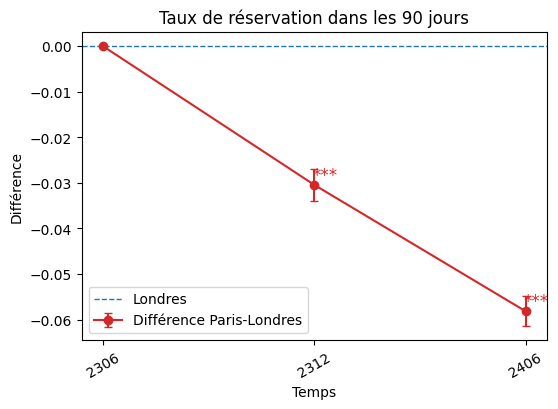

In [319]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

plot_one_did(data_booking, axes=None, i=0, var='booking_rate_l90d', title='Taux de réservation dans les 90 jours')


In [33]:
# df['time']=df['time'].astype(str)
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data, get_ddd_effect

var="booking_rate_l90d"
agg_all=get_cf_data(df, model_basic, var=var)
ddd=get_ddd_effect(model=model_basic, var=var)

display(agg_all)
display(ddd)


ddd of booking_rate_l90d: -0.027716668465284693
booking_rate_l90d


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.162585,0.162585,booking_rate_l90d
1,0,2312,0.072095,0.072095,booking_rate_l90d
2,0,2406,0.119446,0.119446,booking_rate_l90d
3,1,2306,0.213811,0.213811,booking_rate_l90d
4,1,2312,0.102370,0.102370,booking_rate_l90d
5,1,2406,0.076108,0.103825,booking_rate_l90d


,variable,coef,se,pval,sig,ci_low,ci_high
0,booking_rate_l90d,-0.027717,0.001631,1.024722e-64,***,-0.030914,-0.02452


***


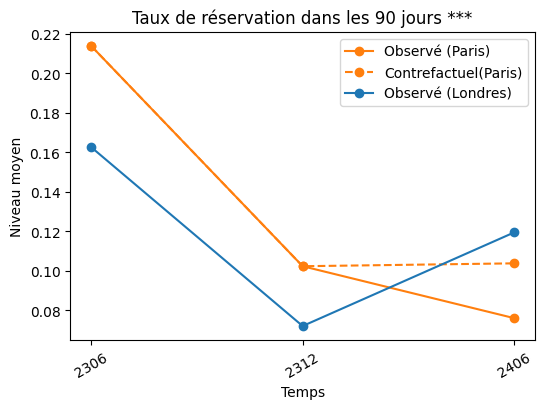

In [36]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_cf

ddd_sig=ddd[ddd['variable']==var]['sig'].loc[0]
print(ddd_sig)

plot_one_cf(agg_all, axes=None, i=0,  var=var, ddd_sig=ddd_sig, title='Taux de réservation dans les 90 jours')


## effets des tactiques

In [37]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_predict_curve

pred_df= plot_predict_curve(model, df,  var="authenticité")
pred_df.head()

default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'in_paris': np.int64(0)}


,host_identity_verified,host_is_superhost,host_response_time,room_type,instant_bookable,time,review_scores_rating,has_rating,number_of_reviews_ltm,years_since_host,...,lang_en,lang_fr,text_length,price,availability_90,in_paris,authenticité,y,low,high
0,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-2.053085,0.165655,0.154678,0.176631
1,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-2.014349,0.165655,0.154678,0.176631
2,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.975614,0.165655,0.154678,0.176631
3,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.936879,0.165655,0.154678,0.176631
4,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.898144,0.165655,0.154678,0.176631


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


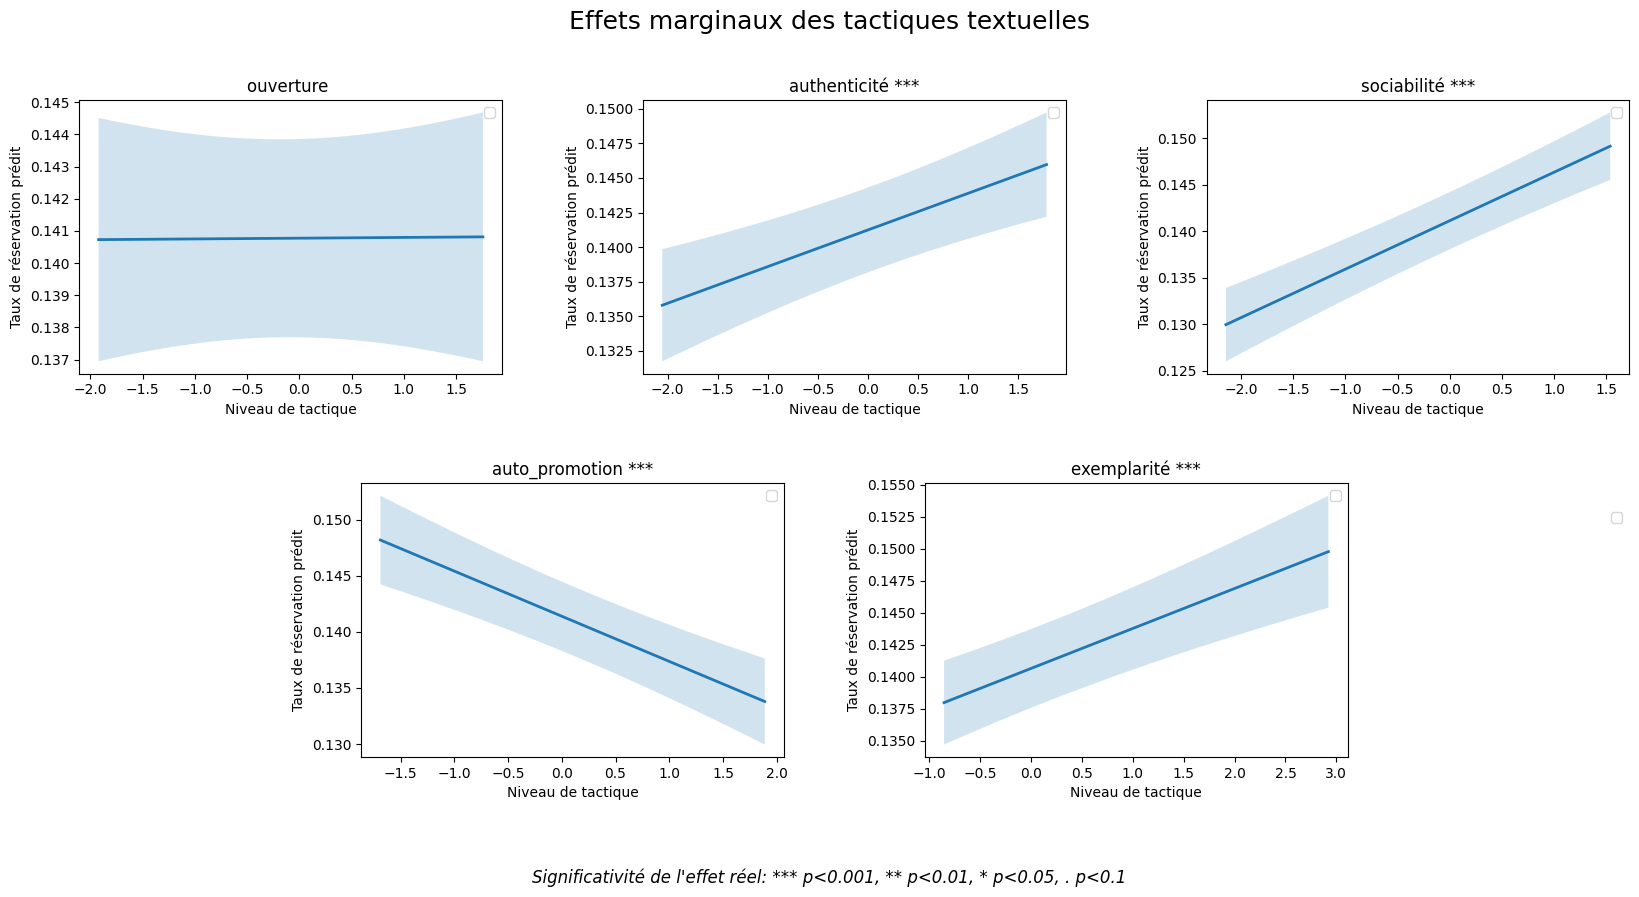

In [200]:
df=df_all.copy()
model=model_basic

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# city='paris'
# times=['2024',"2023"]


for i, var in enumerate(tactics_bio):
    ax = axes[i]
    # for time in times:
    pred_df = plot_predict_curve(model, df, var)
    sig=p_to_sig(model.pvalues[var])
    
    ax.plot(pred_df[var], pred_df["y"], linewidth=2)
    ax.fill_between(pred_df[var], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(f"{var} {sig}")
    ax.set_xlabel("Niveau de tactique")
    ax.set_ylabel("Taux de réservation prédit")


# --------------------legend------------------------
fig.suptitle(
    "Effets marginaux des tactiques textuelles",
    fontsize=18,
    y=0.98 #大标题到子图的距离
)

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.43)# legend (x, y)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------

In [41]:
def plot_categorical_effect(model, df, var, sample_n=5000):
    import pandas as pd
    
    # 抽样（关键！）
    base = df.sample(sample_n, random_state=0).copy()
    
    categories = df[var].dropna().unique()
    
    results = []
    for cat in categories:
        # print(cat)
        
        base[var] = cat
        yhat = model.predict(base)   # 🚀 快很多
        term=f"C({var})[T.{cat}]"
        
        if term not in list(model.params.index):
            sig = ""
        else:   
            sig = p_to_sig(float(model.pvalues[term]))
        
        results.append({
            "variable":var,
            "category": cat,
            "y": yhat.mean(),
            "sig": sig
        })
    return pd.DataFrame(results)

pred_df = plot_categorical_effect(model_basic, df, var="host_picture_type")
display(pred_df)


,variable,category,y,sig
0,host_picture_type,life_style,0.116065,
1,host_picture_type,pro_style,0.118392,**
2,host_picture_type,no_person,0.109621,***


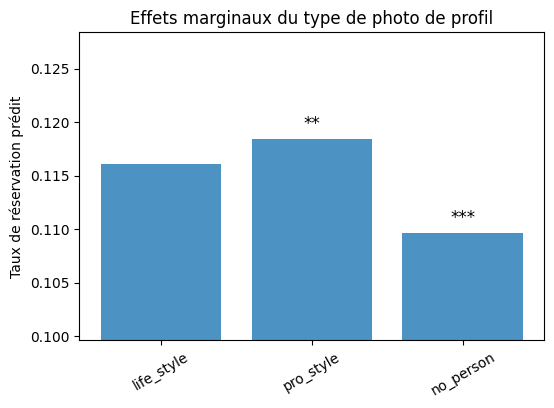

In [43]:
def plot_cat_effect(df_plot):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    ax = plt.gca()

    ax.bar(df_plot["category"], df_plot["y"], alpha=0.8)

    for i, row in df_plot.iterrows():
        ax.text(i, row["y"] + 0.001, row["sig"],
                ha='center', fontsize=12)
    
    ax.set_ylabel("Taux de réservation prédit")
    ax.set_title("Effets marginaux du type de photo de profil")
    ax.tick_params(axis="x", rotation=30)

    plt.ylim(min(df_plot["y"]) - 0.01, max(df_plot["y"]) + 0.01)
    plt.show()
plot_cat_effect(pred_df)

,variable,category,y,sig
0,host_is_superhost,f,0.113674,
1,host_is_superhost,t,0.119241,***


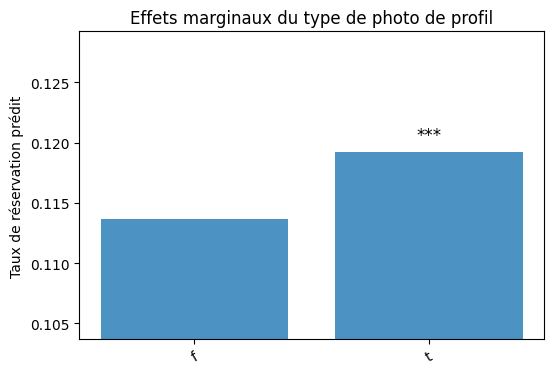

In [44]:

pred_df = plot_categorical_effect(model_basic, df, var="host_is_superhost")
display(pred_df)
plot_cat_effect(pred_df)

## model inetraction

In [45]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf

from utils import modeling_did
tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

# path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
# df_all=pd.read_csv(path_df)
# print(df_all.shape)

In [46]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64


In [47]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(host_picture_type) +"
        "C(time) +"
        "in_paris * C(time) *(C(host_picture_type) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
      
)
  
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"

df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2601.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:05:43   Log-Likelihood:                 89010.
No. Observations:              266852   AIC:                        -1.779e+05
Df Residuals:                  266782   BIC:                        -1.771e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### effets réels des tactiques dans les groups

In [95]:
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data_interaction,get_ddd_effect_interaction

var="authenticité"
ddd=get_ddd_effect_interaction(model_interaction, var=var)

display(ddd)

,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175


In [96]:
importlib.reload(modeling_did)
from utils.modeling_did import get_real_cf_effect_data
tactics_vars=["authenticité"]

ddd=results = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_vars
])

df_plot=get_real_cf_effect_data(model=model_interaction, tactics=tactics_vars, ddd_df=ddd)
display(ddd)
display(df_plot)


authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175


,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,authenticité,0.009019,0.009019,0.001487,1.315256e-09,***,0.006105,0.011933
1,2312,0,authenticité,-0.005589,-0.005589,0.001509,2.132456e-04,***,-0.008547,-0.002631
2,2406,0,authenticité,0.003519,0.003519,0.001411,1.265763e-02,*,0.000753,0.006285
3,2306,1,authenticité,0.013192,0.013192,0.001730,2.420286e-14,***,0.009801,0.016582
4,2312,1,authenticité,0.000148,0.000148,0.001767,9.332312e-01,,-0.003314,0.003610
5,2406,1,authenticité,-0.000873,0.009256,0.001411,5.361321e-01,,-0.003638,0.001892


0
1


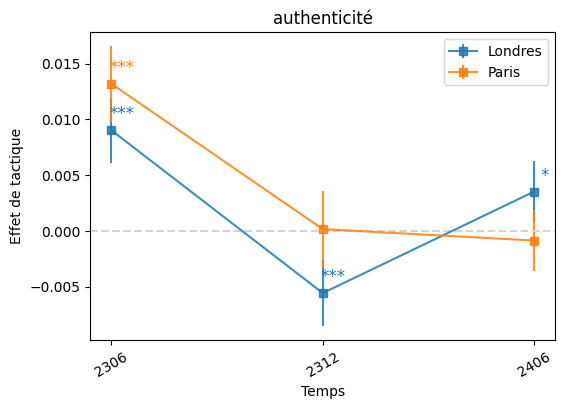

In [274]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect

# var="C(host_picture_type)[T.no_person]"
var="authenticité"
plot_one_real_effect(df_plot=df_plot, var=var)


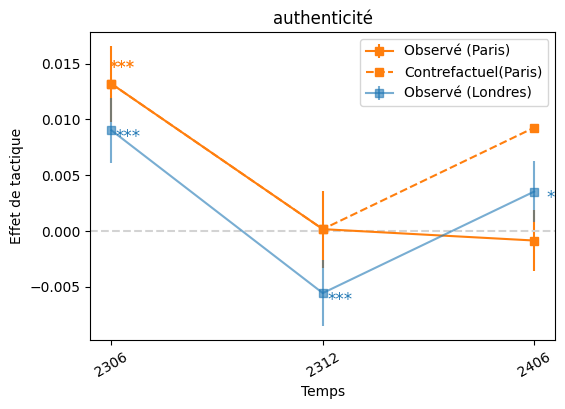

In [278]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_cf_effect

var="authenticité"
plot_one_real_cf_effect(df_plot, var, axes=None, i=0, title=None)


In [105]:
importlib.reload(modeling_did)
from utils.modeling_did import get_real_cf_effect_data

tactics_vars=[
    'ouverture',
    "authenticité",
    "sociabilité",
    'auto_promotion',
    "exemplarité",
    'C(host_picture_type)[T.no_person]',
    'C(host_picture_type)[T.pro_style]',
]
# tactics_vars=["authenticité"]

ddd=results = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_vars
])

df_plot=get_real_cf_effect_data(model=model_interaction, tactics=tactics_vars, ddd_df=ddd)
display(ddd)
display(df_plot)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003793,0.002994,0.205081,,-0.009661,0.002074
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175
0,sociabilité,-0.003074,0.002907,0.290375,,-0.008772,0.002624
0,auto_promotion,0.002930,0.003018,0.331754,,-0.002986,0.008846
0,exemplarité,0.001896,0.002783,0.495737,,-0.003559,0.007350
0,C(host_picture_type)[T.no_person],0.016284,0.004194,0.000103,***,0.008064,0.024503
0,C(host_picture_type)[T.pro_style],-0.004110,0.004022,0.306761,,-0.011993,0.003772


,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,ouverture,0.000727,0.000727,0.001471,6.213242e-01,,-0.002156,0.003610
1,2312,0,ouverture,0.000103,0.000103,0.001491,9.449522e-01,,-0.002819,0.003025
2,2406,0,ouverture,0.003065,0.003065,0.001405,2.913877e-02,*,0.000311,0.005819
3,2306,1,ouverture,-0.005281,-0.005281,0.001725,2.205614e-03,**,-0.008662,-0.001899
4,2312,1,ouverture,-0.000925,-0.000925,0.001763,5.996478e-01,,-0.004380,0.002529
5,2406,1,ouverture,-0.001756,0.002037,0.001367,1.987189e-01,,-0.004435,0.000922
6,2306,0,authenticité,0.009019,0.009019,0.001487,1.315256e-09,***,0.006105,0.011933
7,2312,0,authenticité,-0.005589,-0.005589,0.001509,2.132456e-04,***,-0.008547,-0.002631
8,2406,0,authenticité,0.003519,0.003519,0.001411,1.265763e-02,*,0.000753,0.006285
9,2306,1,authenticité,0.013192,0.013192,0.001730,2.420286e-14,***,0.009801,0.016582


0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\2531809930.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


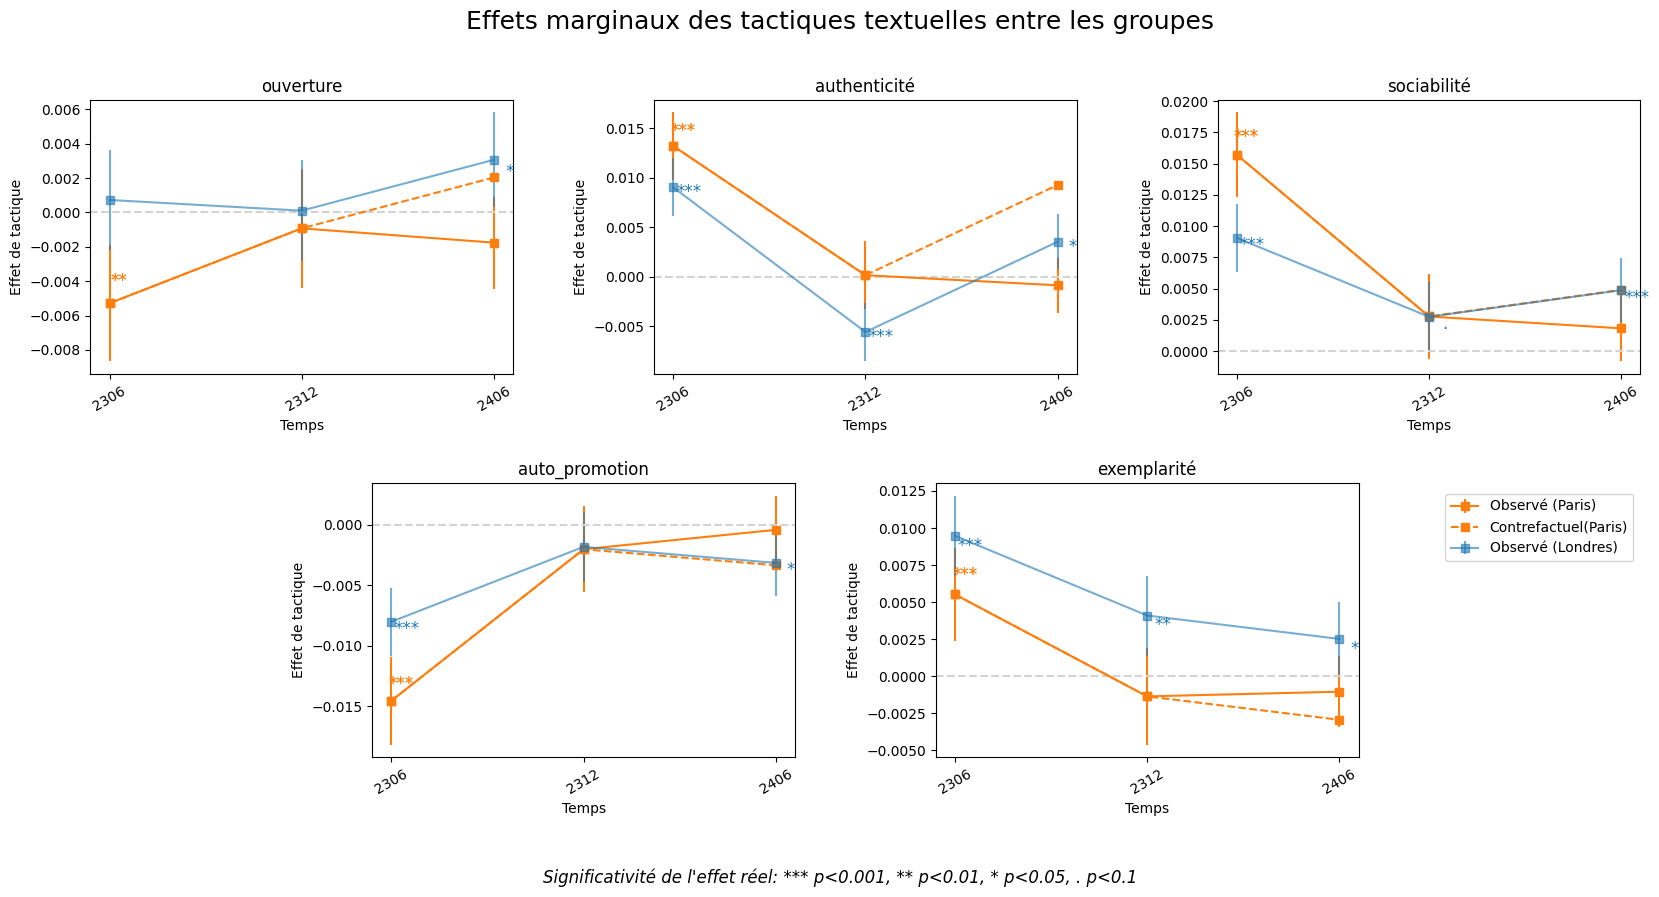

In [303]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect, plot_one_real_cf_effect


# df=df_all.copy()
# model=model_interaction

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# --------------------------------------------


## plot
for i, var in enumerate(tactics_bio):
    print(i, var)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i)



# --------------------legend------------------------
fig.suptitle(
        "Effets marginaux des tactiques textuelles entre les groupes",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------




# ps. star represents the significance of the tactic at this point in this city✔
# legend remove✔
# + contrefactual?? auto+socio积极策略受到消极影响，消极策略auto受到积极效果✔
# 虚线在上说明受到消极影响，虚线在下说明有积极影响

## 新房东专注于authen+socio??

# 补上ddd✔

# 新老房东的booking 
# 新房东的描述：不一定是全新的房东，而是reactivated host

# try is_smiling, age, gender...


0 C(host_picture_type)[T.no_person]
1 C(host_picture_type)[T.pro_style]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\4044399905.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


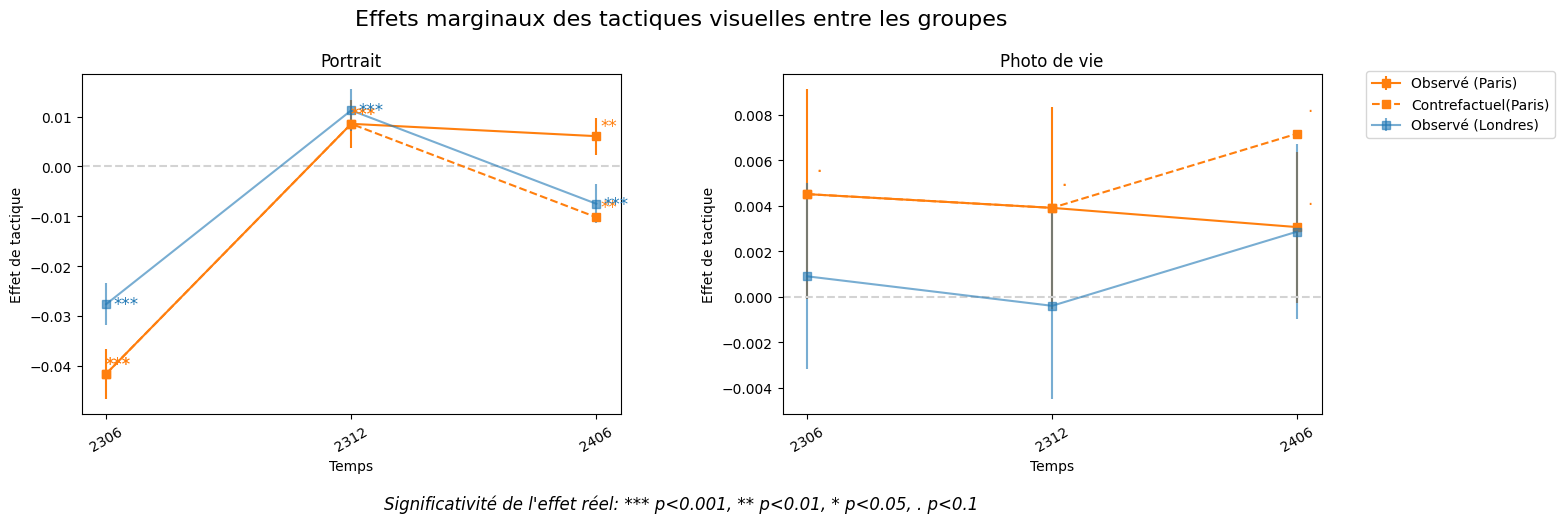

In [304]:

import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect



## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


## plot
tactics_pic=[
 'C(host_picture_type)[T.no_person]',
 'C(host_picture_type)[T.pro_style]'
]
title_pic=['Portrait', 'Photo de vie']

title_map=dict(zip(tactics_pic, title_pic))

for i, var in enumerate(tactics_pic):
    print(i, var)
    plot_one_real_cf_effect(df_plot=df_plot, axes=axes, i=i, var=var, title=title_map.get(var,""))



## ---legend 2facets----
fig.suptitle(
        "Effets marginaux des tactiques visuelles entre les groupes",
        fontsize=16,
        y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()




## JUST DID

In [ ]:
## 不需要包括in_paris:C(time)[T.2312]没有涉及到var!
# 真实效应的组成：
# london 2306: authenticité 
# london 2312 :  authenticité + C(time)[T.2312]:authenticité
# london 2406 :  authenticité + C(time)[T.2406]:authenticité

# paris 2306: authenticité + in_paris:authenticité
# paris 2312 : authenticité + in_paris:authenticité + C(time)[T.2312]: authenticité + in_paris:C(time)[T.2312]:authenticité
# paris 2406 : authenticité + in_paris:authenticité + C(time)[T.2406]: authenticité + in_paris:C(time)[T.2406]:authenticité

# delta 2306: in_paris:authenticité
# delta 2312 : in_paris:authenticité +  in_paris:C(time)[T.2312]:authenticité
# delta 2406 : in_paris:authenticité +  in_paris:C(time)[T.2312]:authenticité

# in_paris:authenticité重复！（设置为hline）?



In [226]:
# FOR CHECK
model=model_interaction
var="authenticité"
b_paris = model.params[f"in_paris:{var}"]
b_2312 = model.params.get(f"in_paris:C(time)[T.2312]:{var}", 0)
b_2406 = model.params.get(f"in_paris:C(time)[T.2406]:{var}", 0)
print('coef:',b_paris, b_2312, b_2406)

p_paris = model.pvalues[f"in_paris:{var}"]
p_2312 = model.pvalues.get(f"in_paris:C(time)[T.2312]:{var}", 0)
p_2406 = model.pvalues.get(f"in_paris:C(time)[T.2406]:{var}", 0)
print('pvalues:',p_paris, p_2312, p_2406)


diff_2306 = b_paris
diff_2312 = b_paris + b_2312
diff_2406 = b_paris + b_2406
print('diff:', diff_2306, diff_2312, diff_2406)
print("ddd:", diff_2406-diff_2312)


coef: 0.004172958724902155 0.0015639002229617708 -0.00856469197903868
pvalues: 0.06616811955539265 0.6284086775283616 0.0043843274796398985
diff: 0.004172958724902155 0.005736858947863925 -0.004391733254136524
ddd: -0.01012859220200045


In [305]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo

results_did=[]
for var in tactics_vars:
    print(var)
    specs_did = [   
                # paris:
                ("2306", [f"in_paris:{var}"]),
                ("2312", [
                    f"in_paris:{var}",
                    f"in_paris:C(time)[T.2312]:{var}", 
                ]),
                ("2406", [
                    f"in_paris:{var}",
                    f"in_paris:C(time)[T.2406]:{var}", 
                ])  
            ]
    for time, terms in specs_did:    
        effect, se, pval, ci_low, ci_high = linear_combo(model=model_interaction, terms=terms)    
        results_did.append({
            "time":time,
            "variable":var,
            "effect": effect,
            "se": se,
            "pval": pval,
            "sig":p_to_sig(pval),
            "ci_low": ci_low,
            "ci_high": ci_high
            })
df_plot_did=pd.DataFrame(results_did)
display(df_plot_did)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]


,time,variable,effect,se,pval,sig,ci_low,ci_high
0,2306,ouverture,-0.006007,0.002267,8.057439e-03,**,-0.010451,-0.001564
1,2312,ouverture,-0.001028,0.002307,6.559004e-01,,-0.005551,0.003494
2,2406,ouverture,-0.004822,0.001958,1.380562e-02,*,-0.008659,-0.000984
3,2306,authenticité,0.004173,0.002271,6.616812e-02,.,-0.000279,0.008625
4,2312,authenticité,0.005737,0.002313,1.311132e-02,*,0.001204,0.010269
5,2406,authenticité,-0.004392,0.001985,2.690685e-02,*,-0.008282,-0.000502
6,2306,sociabilité,0.006652,0.002202,2.520493e-03,**,0.002336,0.010968
7,2312,sociabilité,0.000024,0.002227,9.915097e-01,,-0.004341,0.004388
8,2406,sociabilité,-0.003050,0.001875,1.037720e-01,,-0.006725,0.000625
9,2306,auto_promotion,-0.006527,0.002306,4.647050e-03,**,-0.011047,-0.002008


,time,variable,effect,se,pval,sig,ci_low,ci_high
3,2306,authenticité,0.004173,0.002271,0.066168,.,-0.000279,0.008625
4,2312,authenticité,0.005737,0.002313,0.013111,*,0.001204,0.010269
5,2406,authenticité,-0.004392,0.001985,0.026907,*,-0.008282,-0.000502


axis x: [0, 1, 2]


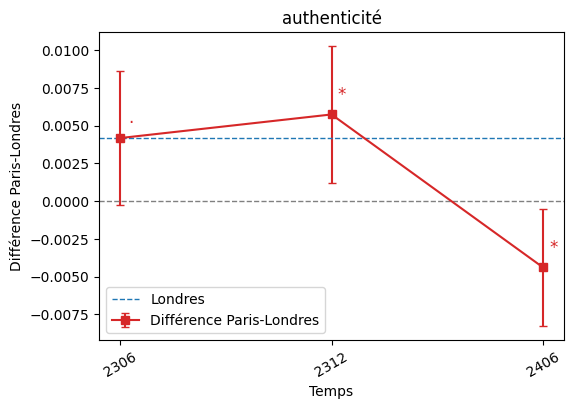

In [306]:

importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction

plot_one_did_interaction(df_plot=df_plot_did, var='authenticité')


0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\204459451.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


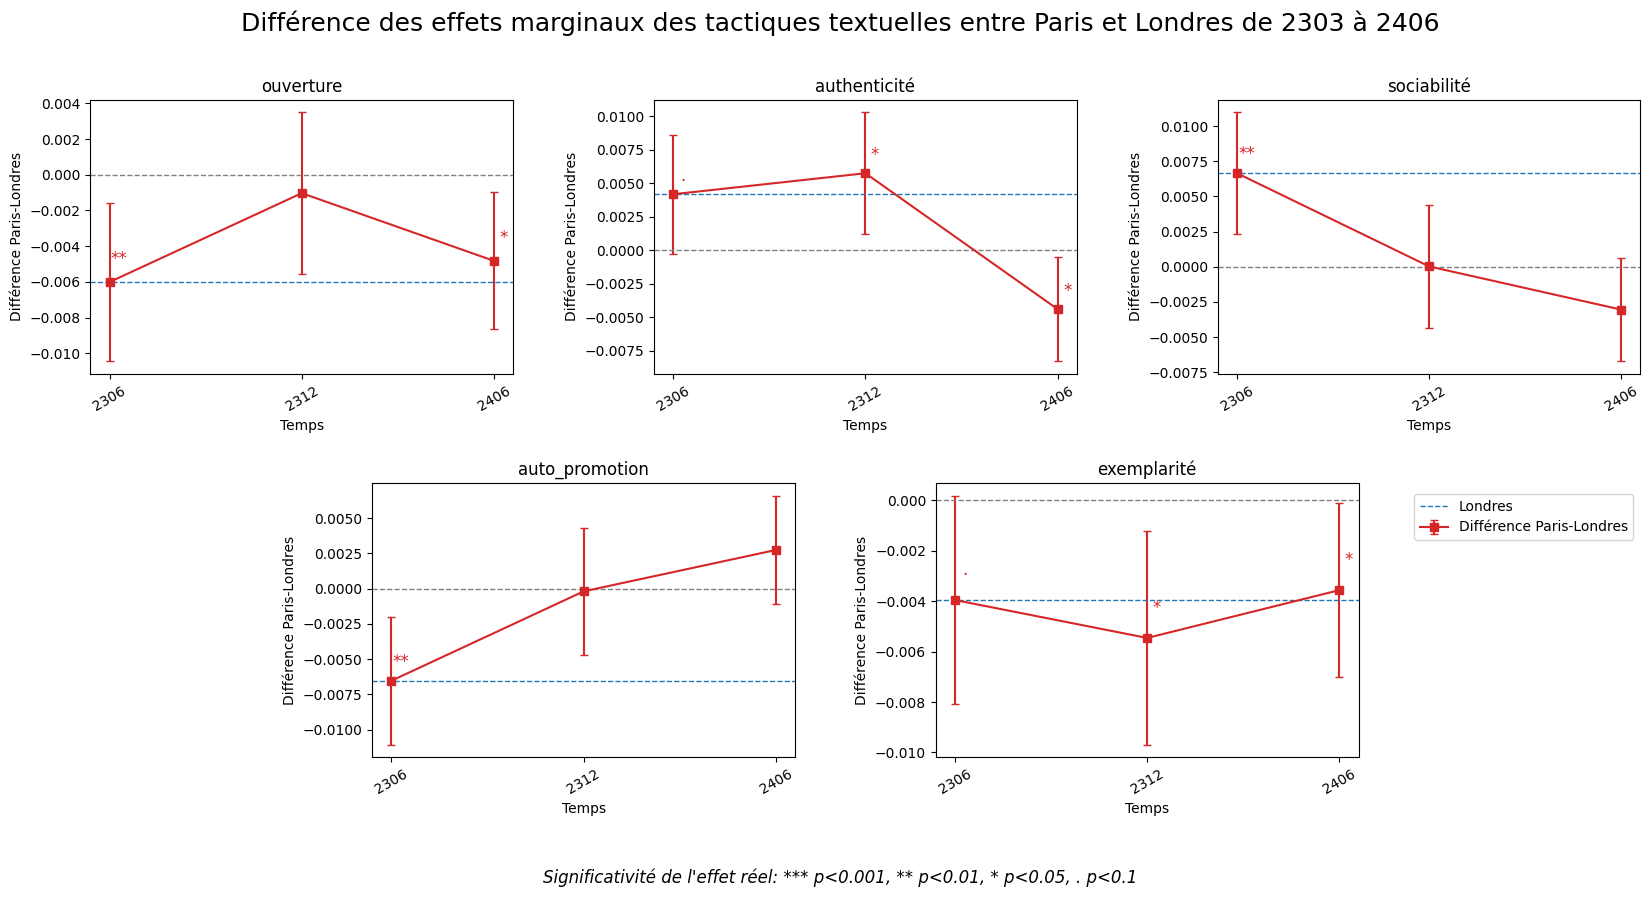

In [318]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction


# df=df_all.copy()
# model=model_interaction

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# --------------------------------------------


## plot
for i, var in enumerate(tactics_bio):
    print(i, var)
    plot_one_did_interaction(df_plot=df_plot_did, var=var, axes=axes, i=i)

fig.suptitle(
        "Différence des effets marginaux des tactiques textuelles entre Paris et Londres de 2303 à 2406",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------




axis x: [0, 1, 2]
axis x: [0, 1, 2]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3147077756.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


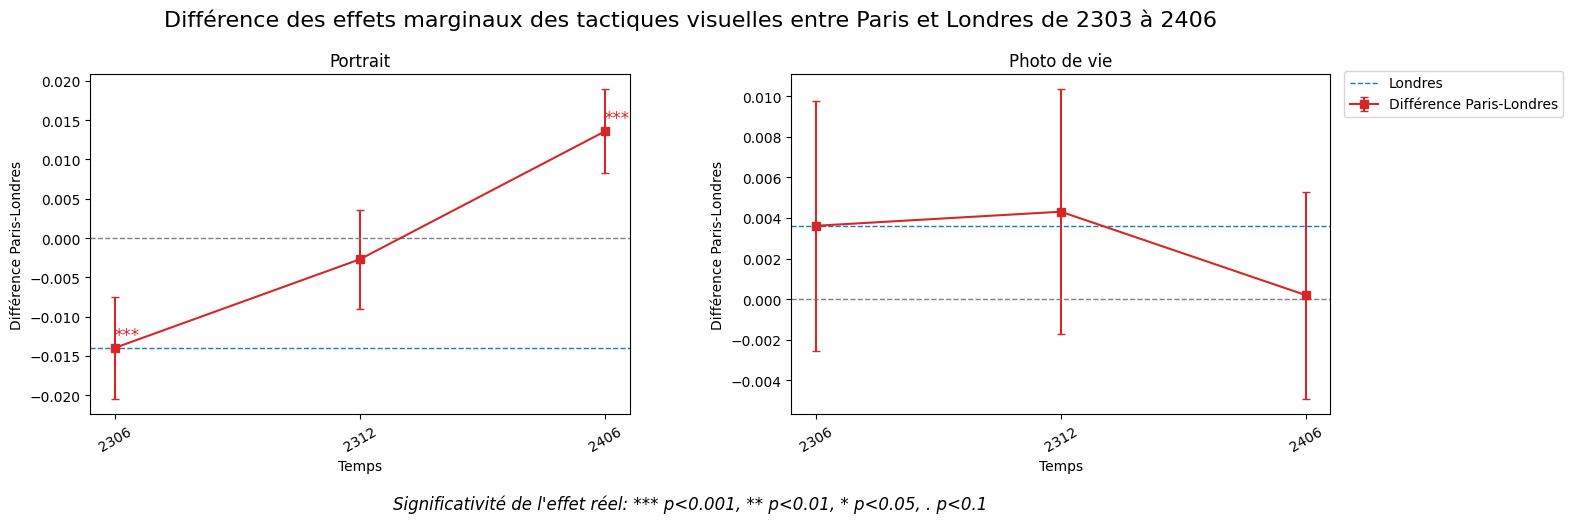

In [314]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


## plot
tactics_pic=[
 'C(host_picture_type)[T.no_person]',
 'C(host_picture_type)[T.pro_style]'
]
title_pic=['Portrait', 'Photo de vie']

title_map=dict(zip(tactics_pic, title_pic))

for i, var in enumerate(tactics_pic):
    # print(i, var)
    plot_one_did_interaction(df_plot=df_plot_did, axes=axes, i=i, var=var, title=title_map.get(var,""))


## ---legend 2facets----
fig.suptitle(
        "Différence des effets marginaux des tactiques visuelles entre Paris et Londres de 2303 à 2406",
        fontsize=16,
        y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
